# QTM 151 Final Project
### How strong is the relationship between a presidential candidate/governor winning a given county vs. a Congressperson of the same party winning that county?
#### Jillian Koenig, Ayushi Chowksey, Shraddha Bandlamudi, Johnny Sanchez


The goal of our project is to determine how strong the relationship is between a presidential candidate or governor winning a given county vs. a Congressperson of the same party winning that county. We would expect for there to be a correlation between candidates for various governmental positions from the same party winning in the same county due to the same subset of people voting in that county. For example, if a democratic candidate for governor wins in Dekalb county, we would expect to see a democratic Congressperson also win in Dekald county. We are especially interested in exploring the US 2020 Election data since the midterm elections are next fall. It would be interesting to see if our findings apply to the 2026 elections. 

ADD RESULTS

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
df_gubernatorial = pd.read_csv("4-US_Election_2020/governors_county_candidate.csv")
df_presidential = pd.read_csv("4-US_Election_2020/president_county_candidate.csv")
df_senate = pd.read_csv("4-US_Election_2020/senate_county_candidate.csv")

display(df_gubernatorial.head())
display(df_presidential.head())
display(df_senate.head())

,state,county,candidate,party,votes,won
0,Delaware,Kent County,John Carney,DEM,44352,True
1,Delaware,Kent County,Julianne Murray,REP,39332,False
2,Delaware,Kent County,Kathy DeMatteis,IPD,1115,False
3,Delaware,Kent County,John Machurek,LIB,616,False
4,Delaware,New Castle County,John Carney,DEM,191678,True


,state,county,candidate,party,total_votes,won
0,Delaware,Kent County,Joe Biden,DEM,44552,True
1,Delaware,Kent County,Donald Trump,REP,41009,False
2,Delaware,Kent County,Jo Jorgensen,LIB,1044,False
3,Delaware,Kent County,Howie Hawkins,GRN,420,False
4,Delaware,New Castle County,Joe Biden,DEM,195034,True


,state,county,candidate,party,total_votes
0,Delaware,Kent County,Lauren Witzke,REP,38571
1,Delaware,Kent County,Mark Turley,IPD,1553
2,Delaware,Kent County,Nadine Frost,LIB,958
3,Delaware,New Castle County,Lauren Witzke,REP,80081
4,Delaware,New Castle County,Mark Turley,IPD,4277


In [4]:
#finding max votes for each senate election in each county
sen_winners = df_senate.groupby(["state", "county"]).\
    agg(winner_votes = ("total_votes", "max"))
df_senate = pd.merge(left = df_senate,
                         right = sen_winners,
                         on = ["state", "county"],
                         how = "left")
df_senate["winner"] = (df_senate["total_votes"] == df_senate["winner_votes"])

# get the winners in each county and rename columns for gov and pres
winners_gov = df_gubernatorial[df_gubernatorial["won"] == True][["state", "county", "party", "votes"]].copy()
winners_gov = winners_gov.rename(columns={"party":"gov_party", "votes":"gov_votes"})

winners_pres = df_presidential[df_presidential["won"] == True][["state", "county", "party", "total_votes"]].copy()
winners_pres = winners_pres.rename(columns={"party":"pres_party", "total_votes":"pres_votes"})



In [4]:
# merge winners on state and county for pres and gov
df_pg_winners = pd.merge(winners_pres, winners_gov, on=["state", "county"], how="inner")
df_pg_winners.head()

df_pg_winners["same_party"] = (df_pg_winners["pres_party"] == df_pg_winners["gov_party"])

# data cleaning
df_pg_winners = df_pg_winners.dropna(subset=["state", "county"])
df_pg_winners["pres_votes"] = pd.to_numeric(df_pg_winners["pres_votes"], errors="coerce")
df_pg_winners["gov_votes"]  = pd.to_numeric(df_pg_winners["gov_votes"], errors="coerce")
df_pg_winners = df_pg_winners.dropna(subset=["pres_votes", "gov_votes"])

# final check
print("Merged winners shape (counties compared):", df_pg_winners.shape)





Merged winners shape (counties compared): (1025, 7)


In [5]:
#merge winners on state and county for sen and gov
sen_new = df_senate.rename(columns = {"candidate" : "sen_candidate", "party" : "sen_party", "winner": "sen_winner"})
gov_new = df_gubernatorial.rename(columns = {"candidate" : "gov_candidate", "party" : "gov_party", "won": "gov_winner"})
df_sen_gov = pd.merge(left = gov_new[["state", "county", "gov_candidate", "gov_party", "gov_winner"]], 
                          right = sen_new[["state", "county", "sen_candidate", "sen_party", "sen_winner"]],
                          on = ["state", "county"], how = "left")

#querying merged df to only list the winners
df_sg_winners = df_sen_gov.query("sen_winner == True and gov_winner == True")
#find which counties had winners in the same party
df_sg_winners["same_party"] = (df_sen_gov["sen_party"] == df_sen_gov["gov_party"])

# data cleaning
df_sg_winners = df_sg_winners.dropna(subset=["state", "county"])

# final check
print("Merged winners shape (counties compared):", df_sg_winners.shape)

Merged winners shape (counties compared): (451, 9)


/var/folders/td/y0sztfb52kv0s5w7y58nlnsw0000gn/T/ipykernel_97840/3795130853.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sg_winners["same_party"] = (df_sen_gov["sen_party"] == df_sen_gov["gov_party"])


In [6]:
# frequency: same party vs different
same_pg_counts = df_pg_winners["same_party"].value_counts(dropna=False)
print("Same party won gov and pres races (True/False):")
print(same_pg_counts)
print("\nPercentage same party for gov/pres:", same_pg_counts.get(True,0) / df_pg_winners.shape[0] * 100)


# descriptive stats for vote totals (selective)
df_pg_winners[["pres_votes", "gov_votes"]].describe()


# frequency: same party vs different
same_sg_counts = df_sg_winners["same_party"].value_counts(dropna=False)
print("Same party won sen and gov races (True/False):")
print(same_sg_counts)
print("\nPercentage same party for gov/sen:", same_sg_counts.get(True,0) / df_sg_winners.shape[0] * 100)


Same party won gov and pres races (True/False):
same_party
True     720
False    305
Name: count, dtype: int64

Percentage same party for gov/pres: 70.24390243902438
Same party won sen and gov races (True/False):
same_party
False    299
True     152
Name: count, dtype: int64

Percentage same party for gov/sen: 33.70288248337029


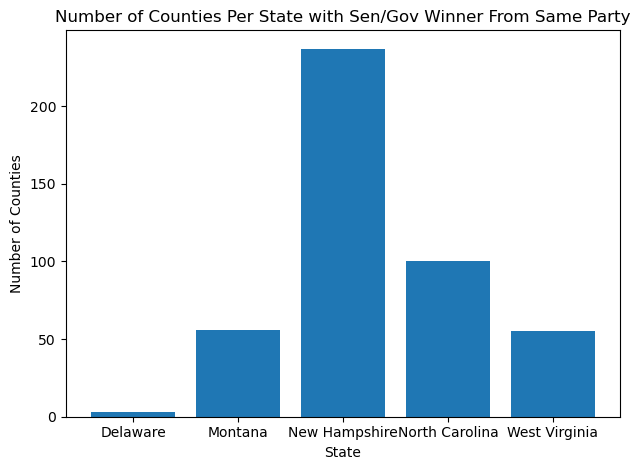

In [23]:
#agg statistics for sen/gov winners 
df_sg_state_counts = df_sg_winners.groupby(by = ["state"]).agg(
    same_party_count_state = ("same_party", "count")
).reset_index()

#Plot: Governor vs. Senator winners of same party by state
plt.bar(df_sg_state_counts["state"], df_sg_state_counts["same_party_count_state"])
plt.xlabel("State")
plt.ylabel("Number of Counties")
plt.title("Number of Counties Per State with Sen/Gov Winner From Same Party")
plt.tight_layout()





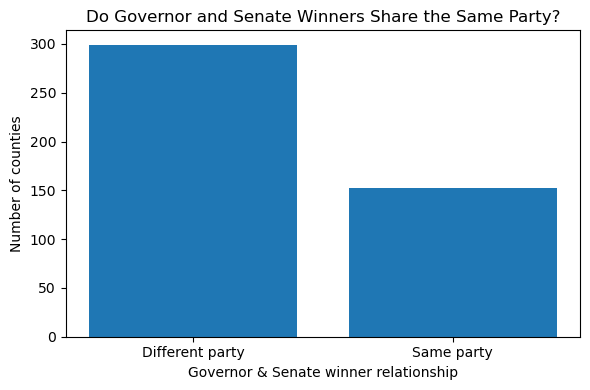

In [10]:
#Plot: Governor vs Senate winners, same party or not


#Turn the counts into a small DataFrame for nicer labels
plot_df = same_sg_counts.rename_axis("same_party").reset_index(name="count")
plot_df["same_party"] = plot_df["same_party"].map({True: "Same party", False: "Different party"})


plt.figure(figsize=(6,4))
plt.bar(plot_df["same_party"], plot_df["count"])
plt.title("Do Governor and Senate Winners Share the Same Party?")
plt.xlabel("Governor & Senate winner relationship")
plt.ylabel("Number of counties")
plt.tight_layout()
plt.show()




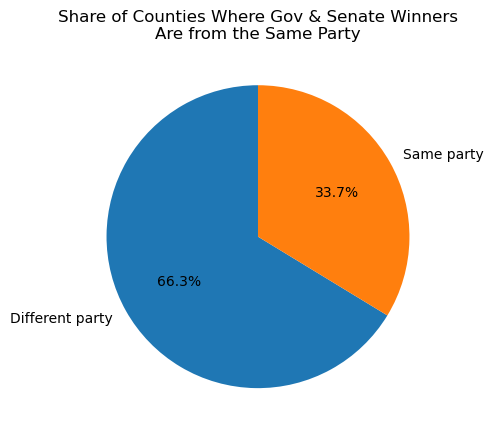

In [11]:
plt.figure(figsize=(5,5))
plt.pie(
    plot_df["count"],
    labels=plot_df["same_party"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Share of Counties Where Gov & Senate Winners\nAre from the Same Party")
plt.tight_layout()
plt.show()


In [42]:
#Descriptive statistics for sen/gov data
df_sen_gov[["state", "county", "gov_party", "sen_party"]].describe()



,state,county,gov_party,sen_party
count,8112,8112,8112,4742
unique,11,864,12,6
top,New Hampshire,Wayne County,DEM,LIB
freq,2844,34,1760,1607


In [43]:
#Descriptive statistics for sen/gov winners data
df_sg_winners[["state", "county", "gov_party", "sen_party"]].describe()

,state,county,gov_party,sen_party
count,451,451,451,451
unique,5,441,2,2
top,New Hampshire,Lincoln County,REP,DEM
freq,237,3,398,256


In [37]:
#Winners of same party broken down by DEM, REP, and other parties
df_sg_winners_dem = df_sg_winners.query("sen_party == 'DEM' & gov_party == 'DEM'")
df_sg_winners_rep = df_sg_winners.query("sen_party == 'REP' & gov_party == 'REP'")
df_sg_winners_other = df_sg_winners.query("sen_party != 'REP' & gov_party != 'REP' & sen_party != 'DEM' & gov_party != 'DEM'")
print(len(df_sg_winners_dem))
print(len(df_sg_winners_rep))
print(len(df_sg_winners_other))


5
147
0
